In [ ]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

import cns
import cns.data_utils as cdu
import pandas as pd
import matplotlib.pyplot as plt
import time
import numpy as np
from sklearn.manifold import MDS


pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


C:\Users\adams\AppData\Local\Temp\ipykernel_56464\45281415.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [8]:
samples_df, cns_df = cdu.main_load("1MB")
cns_df = cns.only_aut(cns.add_total_cn(cns_df))
subs_df = cns.cns_head(cns_df, 400)

In [9]:
start = time.time()
dist_matrix = cns.calc_distances(subs_df)
print(f"Elapsed time: {time.time() - start:.2f} seconds")
dist_matrix.to_csv(cdu.pjoin(cdu.out_path, "LUAD_LUSC_wass_dist.tsv"), sep="\t", index=True, header=True)

Elapsed time: 127.03 seconds


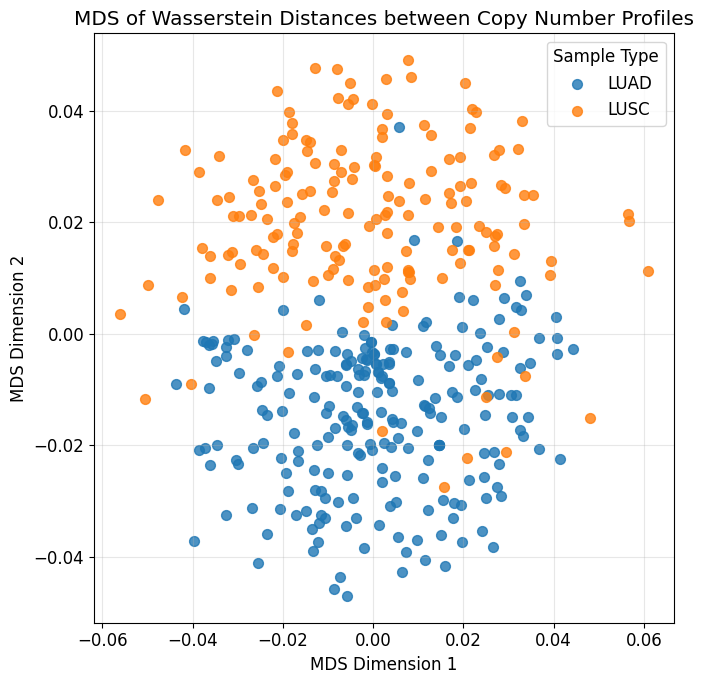

In [11]:

# Get sample metadata (assuming samples_df has metadata we can use)
sample_metadata = samples_df.loc[dist_matrix.index]

# Perform MDS on the distance matrix
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
positions = mds.fit_transform(dist_matrix.values)

# Create a DataFrame with MDS results
mds_df = pd.DataFrame(positions, columns=['MDS1', 'MDS2'], index=dist_matrix.index)

# Merge with metadata (adjust this based on your actual metadata structure)
# If you have a 'type' or 'subtype' column that would be useful for coloring
if 'type' in sample_metadata.columns:  # Adjust column name as needed
    mds_df['type'] = sample_metadata['type']

# Plot MDS results
plt.figure(figsize=(7, 7))

# If type information is available, use it for coloring
if 'type' in mds_df.columns:
    types = mds_df['type'].unique()
    for i, t in enumerate(types):
        mask = mds_df['type'] == t
        plt.scatter(mds_df.loc[mask, 'MDS1'], mds_df.loc[mask, 'MDS2'], 
                   label=t, color=color_map[i % len(color_map)], s=50, alpha=0.8)
    plt.legend(title='Sample Type')
else:
    # Simple plot without grouping
    plt.scatter(mds_df['MDS1'], mds_df['MDS2'], s=50, alpha=0.8)
    
    # Optionally label points with sample IDs (consider only if not too many samples)
    if len(mds_df) <= 30:  # Only add labels if there are few enough points
        for idx in mds_df.index:
            plt.annotate(idx, (mds_df.loc[idx, 'MDS1'], mds_df.loc[idx, 'MDS2']),
                         fontsize=8, alpha=0.7)

plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.title('MDS of Wasserstein Distances between Copy Number Profiles')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Optionally save the MDS results
mds_df.to_csv(cdu.pjoin(cdu.out_path, "LUAD_LUSC_mds_positions.tsv"), sep="\t", index=True)